In [1]:
pip install vaderSentiment textblob wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv('listings_info.csv')

# Drop rows with missing description
df_text = df[['id', 'description', 'neighborhood_overview',
              'review_scores_rating', 'room_type',
              'neighbourhood_cleansed', 'price']].dropna(subset=['description']).copy()

# Parse price
df_text['price'] = df_text['price'].replace('[\$,]', '', regex=True).astype(float)

# Compute VADER sentiment on description
analyzer = SentimentIntensityAnalyzer()
df_text['sentiment_compound'] = df_text['description'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
df_text['sentiment_positive'] = df_text['description'].apply(
    lambda x: analyzer.polarity_scores(str(x))['pos']
)
df_text['sentiment_negative'] = df_text['description'].apply(
    lambda x: analyzer.polarity_scores(str(x))['neg']
)

# Label sentiment
df_text['sentiment_label'] = pd.cut(
    df_text['sentiment_compound'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['Negative', 'Neutral', 'Positive']
)

print(df_text['sentiment_label'].value_counts())
print(df_text['sentiment_compound'].describe())

<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1001/1450385016.py:14: SyntaxWarning: invalid escape sequence '\$'
  df_text['price'] = df_text['price'].replace('[\$,]', '', regex=True).astype(float)


sentiment_label
Positive    8147
Neutral      210
Negative     141
Name: count, dtype: int64
count    8498.000000
mean        0.818404
std         0.256815
min        -0.889700
25%         0.800000
50%         0.920700
75%         0.961600
max         0.995400
Name: sentiment_compound, dtype: float64


Spearman correlation (sentiment vs rating): 0.0138, p=0.2490


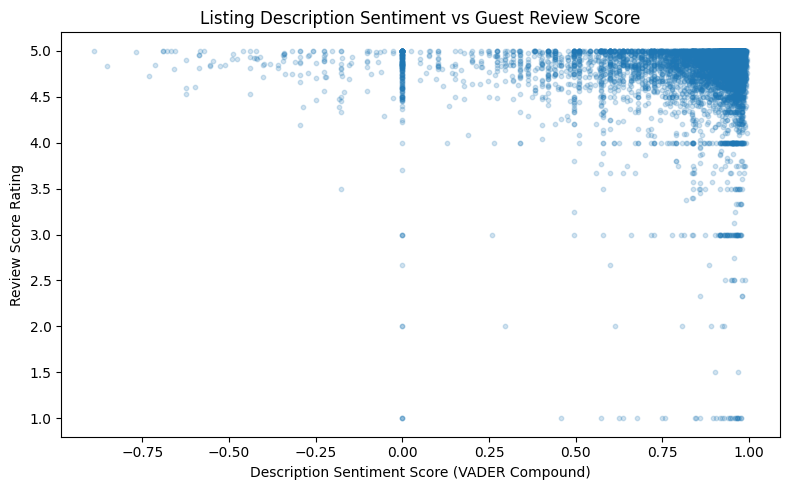

In [3]:
from scipy import stats

# Drop rows missing review score
df_corr = df_text.dropna(subset=['review_scores_rating'])

correlation, pvalue = stats.spearmanr(
    df_corr['sentiment_compound'],
    df_corr['review_scores_rating']
)
print(f"Spearman correlation (sentiment vs rating): {correlation:.4f}, p={pvalue:.4f}")

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df_corr['sentiment_compound'], df_corr['review_scores_rating'],
            alpha=0.2, s=10)
plt.xlabel('Description Sentiment Score (VADER Compound)')
plt.ylabel('Review Score Rating')
plt.title('Listing Description Sentiment vs Guest Review Score')
plt.tight_layout()
plt.savefig('sentiment_vs_rating.png', dpi=150)
plt.show()

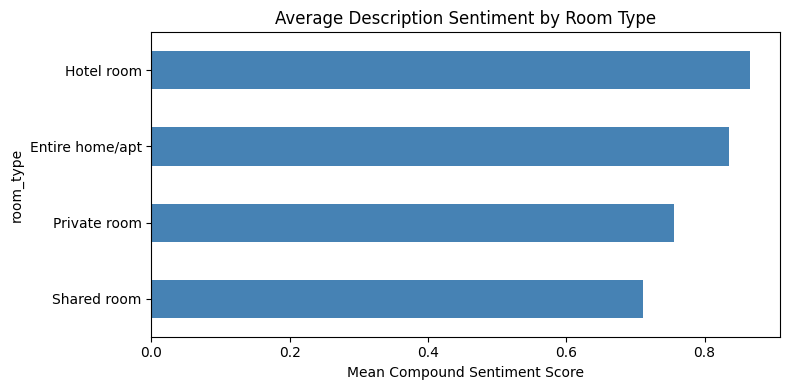

Most positively described neighbourhoods:
 neighbourhood_cleansed
Near South Side    0.912034
Near North Side    0.881545
Loop               0.871917
Forest Glen        0.859280
West Elsdon        0.859200
Name: sentiment_compound, dtype: float64

Least positively described neighbourhoods:
 neighbourhood_cleansed
Archer Heights    0.502943
New City          0.517785
Burnside          0.525467
Hegewisch         0.561233
North Park        0.565741
Name: sentiment_compound, dtype: float64


In [4]:
# Average sentiment by room type
sentiment_by_room = df_text.groupby('room_type')['sentiment_compound'].mean().sort_values()

plt.figure(figsize=(8, 4))
sentiment_by_room.plot(kind='barh', color='steelblue')
plt.title('Average Description Sentiment by Room Type')
plt.xlabel('Mean Compound Sentiment Score')
plt.tight_layout()
plt.savefig('sentiment_by_room.png', dpi=150)
plt.show()

# Top and bottom neighbourhoods by sentiment
sentiment_by_neigh = df_text.groupby('neighbourhood_cleansed')['sentiment_compound'].mean()
top5 = sentiment_by_neigh.nlargest(5)
bot5 = sentiment_by_neigh.nsmallest(5)
print("Most positively described neighbourhoods:\n", top5)
print("\nLeast positively described neighbourhoods:\n", bot5)

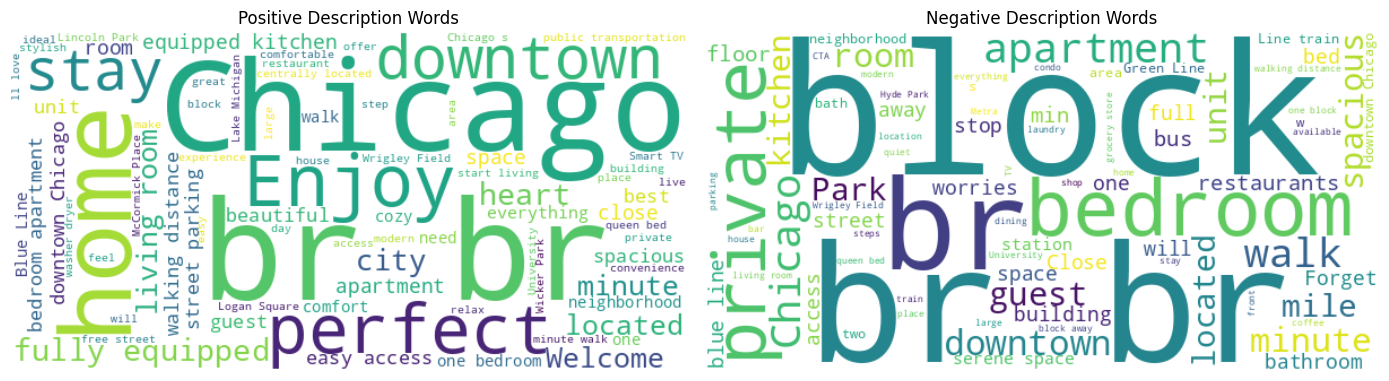

In [5]:
from wordcloud import WordCloud

positive_text = ' '.join(df_text[df_text['sentiment_label'] == 'Positive']['description'].tolist())
negative_text = ' '.join(df_text[df_text['sentiment_label'] == 'Negative']['description'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, text, label in zip(axes, [positive_text, negative_text], ['Positive', 'Negative']):
    wc = WordCloud(width=600, height=300, background_color='white',
                   max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label} Description Words')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

In [8]:
import ast

df_info = pd.read_csv('listings_info.csv')
df_info['price'] = df_info['price'].replace('[$,]', '', regex=True).astype(float)

# Parse amenity lists
def parse_amenities(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df_info['amenity_list'] = df_info['amenities'].apply(parse_amenities)

# Find top N most common amenities
from collections import Counter
all_amenities = [a for sublist in df_info['amenity_list'] for a in sublist]
top_amenities = [a for a, _ in Counter(all_amenities).most_common(30)]
print("Top 30 amenities:", top_amenities)

# Create binary feature matrix
for amenity in top_amenities:
    col_name = 'amenity_' + amenity.lower().replace(' ', '_')[:30]
    df_info[col_name] = df_info['amenity_list'].apply(lambda x: 1 if amenity in x else 0)

amenity_cols = [c for c in df_info.columns if c.startswith('amenity_') and c != 'amenity_list']
print(f"\nAmenity feature matrix: {df_info[amenity_cols].shape}")

Top 30 amenities: ['Smoke alarm', 'Carbon monoxide alarm', 'Kitchen', 'Wifi', 'Hot water', 'Hair dryer', 'Iron', 'Hangers', 'Bed linens', 'Microwave', 'Cooking basics', 'Essentials', 'Self check-in', 'Refrigerator', 'Dishes and silverware', 'Shampoo', 'Fire extinguisher', 'Dedicated workspace', 'Air conditioning', 'Long term stays allowed', 'TV', 'First aid kit', 'Dishwasher', 'Heating', 'Oven', 'Freezer', 'Bathtub', 'Coffee maker', 'Extra pillows and blankets', 'Dining table']

Amenity feature matrix: (8660, 30)


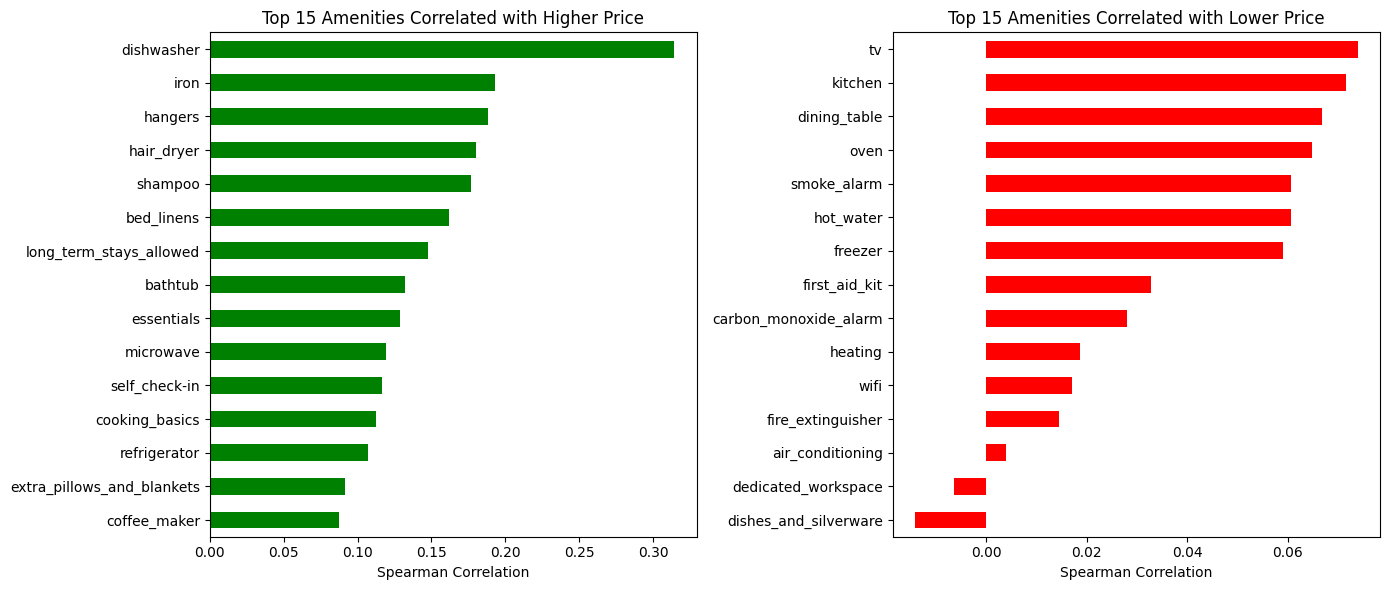

In [9]:
# Which amenities correlate most with higher price?
correlations = {}
for col in amenity_cols:
    corr, _ = stats.spearmanr(df_info[col], df_info['price'].fillna(0))
    correlations[col.replace('amenity_', '')] = corr

corr_series = pd.Series(correlations).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
corr_series.tail(15).plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top 15 Amenities Correlated with Higher Price')
axes[0].set_xlabel('Spearman Correlation')

corr_series.head(15).plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top 15 Amenities Correlated with Lower Price')
axes[1].set_xlabel('Spearman Correlation')

plt.tight_layout()
plt.savefig('amenity_price_correlation.png', dpi=150)
plt.show()

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# Build amenity feature matrix for similarity
amenity_matrix = df_info[amenity_cols].fillna(0).values

# Function: given a listing id, find top N similar listings
def recommend_similar(listing_id, top_n=5):
    idx = df_info[df_info['id'] == listing_id].index
    if len(idx) == 0:
        print("Listing not found")
        return
    idx = idx[0]

    sim_scores = cosine_similarity([amenity_matrix[idx]], amenity_matrix)[0]
    similar_indices = sim_scores.argsort()[::-1][1:top_n+1]  # exclude self

    results = df_info.iloc[similar_indices][['id', 'name', 'room_type',
                                              'neighbourhood_cleansed', 'price']].copy()
    results['similarity_score'] = sim_scores[similar_indices].round(3)
    return results

# Test with first listing
sample_id = df_info['id'].iloc[0]
print(f"Recommendations similar to listing {sample_id}:")
print(recommend_similar(sample_id))

Recommendations similar to listing 2384:
                      id                                               name  \
901             25055595                             Avondale Oasis Floor 3   
2415            51151407                             Avondale Oasis Floor 2   
2781  549225909050662091         1910 Beautiful Restoration! Walk to Beach!   
3035  612179677317950848  Lovely 4 Bedroom Spot located in Charming Old ...   
4875  983470790158014465   Bright 3BR/1BA FREE Park/Laundry Minutes from DT   

            room_type neighbourhood_cleansed  price  similarity_score  
901   Entire home/apt               Avondale   73.0             0.959  
2415  Entire home/apt               Avondale  102.0             0.959  
2781  Entire home/apt              Edgewater  172.0             0.959  
3035  Entire home/apt        Near North Side  588.0             0.957  
4875  Entire home/apt        Lower West Side  180.0             0.957  
